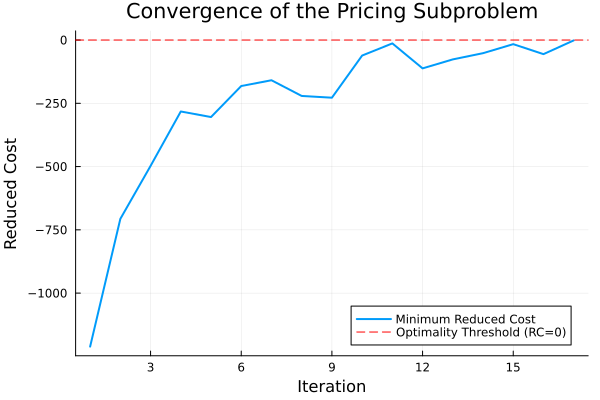


--- Column Generation Complete ---
No more profitable columns found. Optimal LP solution reached.

--- FINAL P-MEDIAN SOLUTION ---
Selected Facilities (p=7): [6, 12, 2, 27, 26, 15, 25]
Objective value: 2898.421640968648 meters
Facility: 6 | Capacity: (23/25) | Clients: [1, 6, 14, 20]
Facility: 12 | Capacity: (22/25) | Clients: [8, 12, 16]
Facility: 2 | Capacity: (23/25) | Clients: [2, 13, 17, 24, 28, 29]
Facility: 27 | Capacity: (25/25) | Clients: [4, 18, 19, 22, 27]
Facility: 26 | Capacity: (23/25) | Clients: [10, 21, 26, 30]
Facility: 15 | Capacity: (19/25) | Clients: [5, 15, 23]
Facility: 25 | Capacity: (21/25) | Clients: [3, 7, 9, 11, 25]


PyObject <folium.folium.Map object at 0x0000021D98A65640>

In [1]:
# -------------------------------------------------------------
#  Code for: "Introduction to Integer Programming and Applications with Julia"
#  Chapter: 6 – Graph problems
#  Section: Exercise 1
#  Author(s): Luiz Henrique Nogueira Lorena
# -------------------------------------------------------------

using JuMP       # Modeling language
using HiGHS      # Solver
using CSV        # For reading CSV files
using DataFrames # For handling data frames
using Distances  # For distance calculations
using Plots      # For plotting
using Random     # For random number generation

# Utility functions for plotting solution on map
include("utils/pmp-n_utils.jl")

# Data structure to hold problem data
mutable struct ProblemData
    n::Int                           # Number of points
    p::Int                           # Number of facilities to open
    C::Int                           # Capacity of each facility
    coordinates::Matrix{Float64}     # Coordinates of points
    distance_matrix::Matrix{Float64} # Distance matrix between points
    demand::Vector{Int}              # Demand at each point
end

# Define a structure to hold column information
mutable struct CPMPColumn
    cost::Float64
    median::Int64
    client_assignments::Vector{Int64}
end

# Function to plot the convergence of reduced costs
function plot_reduced_costs(reduced_cost_history)
    p = Plots.plot(
        1:length(reduced_cost_history), 
        reduced_cost_history,
        label="Minimum Reduced Cost",
        xlabel="Iteration",
        ylabel="Reduced Cost",
        title="Convergence of the Pricing Subproblem",
        legend=:bottomright,
        linewidth=2
    )
    # Add a horizontal line at y=0 to show the convergence target
    Plots.hline!(p, [0], linestyle=:dash, color=:red, label="Optimality Threshold (RC=0)")
    # Display the plot
    display(p)
end

# Function to read coordinates, demands, and compute Haversine distance matrix
function read_data(file_path; p = 7, C = 25)

    # Read CSV file into DataFrame
    data = CSV.read(file_path, DataFrame)

    # Compute Haversine distance matrix
    coordinates = data[:, [:Latitude,:Longitude]] |> Matrix{Float64}
    distance_matrix = Distances.pairwise(Distances.Haversine(), coordinates, dims=1)

    # Extract demand vector
    demands = data[:, :Demand] |> Vector{Int}

    return ProblemData(size(data, 1), p, C, 
                       coordinates,
                       distance_matrix,
                       demands)
end

# Optimized function to create initial columns
function create_initial_columns(data, initial_columns_total)
    columns = Vector{CPMPColumn}(undef, initial_columns_total)
    for id in 1:initial_columns_total
        client_assignments = zeros(Int64, data.n)
        current_capacity = 0
        for i in shuffle(1:data.n)
            if rand() > 0.5 && (current_capacity + data.demand[i] <= data.C)
                client_assignments[i] = 1
                current_capacity += data.demand[i]
            end
        end
        # Find the median (facility) with minimum total assignment cost
        min_cost = Inf
        median = 1
        for i in 1:data.n
            if client_assignments[i] == 1
                cost = sum(client_assignments[j] * data.distance_matrix[i, j] for j in 1:data.n)
                if cost < min_cost
                    min_cost = cost
                    median = i
                end
            end
        end
        columns[id] = CPMPColumn(min_cost, median, client_assignments)
    end
    return columns
end

# Function to solve the master problem (RMP)
function master_problem(data, columns; solve_as_integer=false)

    # Number of clients and columns
    n_clients = data.n
    n_columns = length(columns)
    
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Variables
    if solve_as_integer
        @variable(model, y[1:n_columns], Bin)
    else
        @variable(model, 0 <= y[1:n_columns] <= 1)
    end
    
    # Objective: Minimize the total cost of the selected columns
    @objective(model, Min, sum(y[i] * columns[i].cost for i in 1:n_columns))

    # Constraint: Each client 'j' must be served by at least one selected column
    if solve_as_integer
        @constraint(model, covering_satisfaction[j=1:n_clients], sum(columns[i].client_assignments[j] * y[i] for i in 1:n_columns) == 1)
    else
        @constraint(model, covering_satisfaction[j=1:n_clients], sum(columns[i].client_assignments[j] * y[i] for i in 1:n_columns) >= 1)
    end

    # Constraint: Ensures that exactly 'p' columns are chosen
    @constraint(model, p_median_satisfaction, sum(y) == data.p)

    # Solve the model
    JuMP.optimize!(model)

    # Check the results and return dual prices
    if solve_as_integer
        if JuMP.termination_status(model) == JuMP.OPTIMAL
            return nothing, nothing, JuMP.value.(y)
        else
            error("Final integer problem did not solve to optimality. Status: $(JuMP.termination_status(model))")
            return nothing, nothing, nothing
        end
    else
        if JuMP.termination_status(model) == JuMP.OPTIMAL
            π = JuMP.dual.(covering_satisfaction)
            σ = JuMP.dual(p_median_satisfaction)
            return π, σ, nothing
        else
            error("RMP was not solved to optimality. Status: $(JuMP.termination_status(model))")
        end
    end
end

# Function to solve the pricing subproblem
function sub_problem(data, columns, π, σ)
    n_clients = n_facilities = data.n
    
    # Initialize variables to track the best column found
    minimum_reduced_cost = typemax(Float64)
    new_column_found = false

    # Solving 'n' 0-1 knapsack problems
    for facility_id in 1:n_facilities
        
        # Create the model
        model = JuMP.Model(HiGHS.Optimizer)
        
        # Silent mode (solver output is not printed)
        JuMP.set_silent(model)
    
        # Variables
        @variable(model, x[1:n_clients, 1:n_facilities], Bin)
        
        # Objective: Minimize the reduced cost
        @objective(model, Min, sum((data.distance_matrix[i,facility_id] - π[i]) * x[i,facility_id] for i in 1:n_clients))
        
        # Constraint: ensures that facilities do not exceed their capacity
        @constraint(model, sum(data.demand[i] * x[i,facility_id] for i in 1:n_clients) <= data.C * x[facility_id,facility_id])
    
        # Solve the model
        JuMP.optimize!(model)

        # Check the results
        if JuMP.termination_status(model) == JuMP.OPTIMAL
            
            # Extract the solution
            x_sub = JuMP.value.(x)
            
            # Calculate the cost of the new column
            reduced_cost = objective_value(model)
            reduced_cost -= σ 

            # Store column if accepted
            if reduced_cost < -1e-6
                minimum_reduced_cost = min(minimum_reduced_cost, reduced_cost)
                new_column_found = true
                # Create the new column
                client_assignments = [x_sub[client_id,facility_id] > 0.5 ? 1 : 0 for client_id in 1:n_clients]
                cost = sum((client_assignments[client_id] * data.distance_matrix[client_id,facility_id]) for client_id in 1:n_clients)
                push!(columns, CPMPColumn(cost, facility_id, client_assignments))
            end  
        end    
    end

    return new_column_found, minimum_reduced_cost 
end

# Function to solve the p-median problem using column generation
function solve_cpmedian_gc(file_path; p = 7, C = 25, initial_columns_total = 20, iterations = 100)

    # Vector to store reduced costs for each iteration
    reduced_cost_history = []

    # Read data and compute distance matrix
    data = read_data(file_path)

    # --- 1. Create initial columns ---
    columns = create_initial_columns(data, initial_columns_total)

    # --- 2. Column generation loop ---
    for iteration in 1:iterations
        
        # --- 3. Solve the Restricted Master Problem (RMP) ---
        π, σ, _ = master_problem(data, columns, solve_as_integer = false)

        # --- 4. Solve the Pricing Subproblem ---
        new_column_found, reduced_cost = sub_problem(data, columns, π, σ)

        # --- 5. Check if a new pattern was found ---
        if !new_column_found || reduced_cost > -1e-6
            println("\n--- Column Generation Complete ---")
            println("No more profitable columns found. Optimal LP solution reached.")
            break
        else
            if iteration % 100 == 0
                println("\n--- Iteration: $iteration ---")
                println("New column(s) added with minimum reduced cost: $reduced_cost")
            end
            push!(reduced_cost_history, reduced_cost)
        end
    end

    # --- 6. Solve the Final Integer Problem ---
    _, _, y_values = master_problem(data, columns, solve_as_integer = true)

    # --- 7. Generate reduced cost Plot ---
    plot_reduced_costs(reduced_cost_history)

    # --- 8. Post-process and display the final solution ---
    selected_column_indices = findall(y_values .> 0.5)

    println("\n--- FINAL P-MEDIAN SOLUTION ---")
    println("Selected Facilities (p=$p): $([columns[i].median for i in selected_column_indices])")
    println("Objective value: $(sum([columns[i].cost for i in selected_column_indices])) meters")
    assignments = Dict()
    for column_id in selected_column_indices
        facility = columns[column_id].median
        clients = findall(columns[column_id].client_assignments .== 1)
        assignments[facility] = clients
        total_demand = sum(data.demand[clients])
        println("Facility: $facility | Capacity: ($total_demand/$(data.C)) | Clients: $clients")
    end

    # Plot the final solution on the map
    plot_solution(data.coordinates, assignments, p)
end

# Set random seed for reproducibility
Random.seed!(42)

# Example usage
solve_cpmedian_gc("data/sjc_n=30_p=7_C=25.csv", p = 7, C = 25, initial_columns_total = 1500, iterations = 1500)